### Churn Prediction Model

Data: existing members only (excludes 2018 enrollees, who get a separate
onboarding-focused treatment).
Target: churned (1 = formally cancelled in 2018 OR zero flights in Jul-Dec 2018)
Features: demographics + 2017 behavioral data + tenure (all known before 2018)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/churn_model_data.csv")
print(df.shape)
df.head()

(13727, 29)


,Loyalty Number,Country,Province,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,...,std_monthly_flights_2017,active_months_2017,redemption_rate_2017,flights_fall_2017,flights_spring_2017,flights_summer_2017,flights_winter_2017,months_since_last_flight_2017,churned,tenure_months
0,480934,Canada,Ontario,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,...,1.678744,7.0,0.012701,2.0,4.0,10.0,2.0,0.0,0,22
1,549612,Canada,Alberta,Male,College,NaN,Divorced,Star,3839.61,Standard,...,2.020726,8.0,0.021779,7.0,9.0,9.0,6.0,1.0,0,21
2,429460,Canada,British Columbia,Male,College,NaN,Single,Star,3839.75,Standard,...,1.370689,7.0,0.016291,4.0,6.0,3.0,3.0,1.0,1,41
3,608370,Canada,Ontario,Male,College,NaN,Single,Star,3839.75,Standard,...,1.758098,9.0,0.025892,5.0,10.0,5.0,4.0,0.0,0,58
4,530508,Canada,Quebec,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,...,1.443376,4.0,0.000000,2.0,2.0,4.0,3.0,1.0,0,38


### 1. Safety check: handle any remaining NaNs before modeling

In [14]:
print("NaNs before fix:")
print(df.isna().sum()[df.isna().sum() > 0])

num_cols_check = df.select_dtypes(include=[np.number]).columns
for col in num_cols_check:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nNaNs after fix:", df.isna().sum().sum())

NaNs before fix:
Salary    3491
dtype: int64

NaNs after fix: 0


### 2. Prepare features and target

In [15]:
from sklearn.model_selection import train_test_split

drop_cols = ['Loyalty Number', 'Country', 'churned']
X = df.drop(columns=drop_cols)
y = df['churned']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)
print("\nNaNs in X:", X.isna().sum().sum())

Categorical columns: ['Province', 'Gender', 'Education', 'Marital Status', 'Loyalty Card', 'Enrollment Type']
Numeric columns: ['Salary', 'CLV', 'Enrollment Year', 'Enrollment Month', 'Salary_Missing', 'total_flights_2017', 'total_distance_2017', 'total_points_accum_2017', 'total_points_redeemed_2017', 'total_dollar_redeemed_2017', 'avg_monthly_flights_2017', 'std_monthly_flights_2017', 'active_months_2017', 'redemption_rate_2017', 'flights_fall_2017', 'flights_spring_2017', 'flights_summer_2017', 'flights_winter_2017', 'months_since_last_flight_2017', 'tenure_months']

NaNs in X: 0


C:\Users\hp\AppData\Local\Temp\ipykernel_3524\551450394.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


### 3. One-hot encode categoricals

In [16]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(X_encoded.shape)
print("NaNs in X_encoded:", X_encoded.isna().sum().sum())
X_encoded.head()

(13727, 39)
NaNs in X_encoded: 0


,Salary,CLV,Enrollment Year,Enrollment Month,Salary_Missing,total_flights_2017,total_distance_2017,total_points_accum_2017,total_points_redeemed_2017,total_dollar_redeemed_2017,...,Province_Yukon,Gender_Male,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single,Loyalty Card_Nova,Loyalty Card_Star
0,83236.0,3839.14,2016,2,0,18.0,25352.0,25352.0,322.0,58.0,...,False,False,False,False,False,False,True,False,False,True
1,73947.0,3839.61,2016,3,1,31.0,36136.0,36136.0,787.0,142.0,...,False,True,True,False,False,False,False,False,False,True
2,73947.0,3839.75,2014,7,1,16.0,22957.0,22957.0,374.0,67.0,...,False,True,True,False,False,False,False,True,False,True
3,73947.0,3839.75,2013,2,1,24.0,33369.0,33369.0,864.0,156.0,...,False,True,True,False,False,False,False,True,False,True
4,103495.0,3842.79,2014,10,0,11.0,19886.0,19886.0,0.0,0.0,...,False,True,False,False,False,False,True,False,False,True


### 4. Train/test split (stratified)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Churn rate:", y_train.mean().round(3))
print("Test:", X_test.shape, "Churn rate:", y_test.mean().round(3))
print("NaNs in X_train:", X_train.isna().sum().sum())

Train: (10981, 39) Churn rate: 0.163
Test: (2746, 39) Churn rate: 0.163
NaNs in X_train: 0


### 5. Baseline model: Logistic Regression

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 3))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2298
           1       0.68      0.70      0.69       448

    accuracy                           0.90      2746
   macro avg       0.81      0.82      0.81      2746
weighted avg       0.90      0.90      0.90      2746

ROC AUC: 0.861


### 6. Stronger model: Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=20,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      2298
           1       0.67      0.70      0.69       448

    accuracy                           0.90      2746
   macro avg       0.81      0.82      0.81      2746
weighted avg       0.90      0.90      0.90      2746

ROC AUC: 0.889


### 7. Confusion matrix (Random Forest)

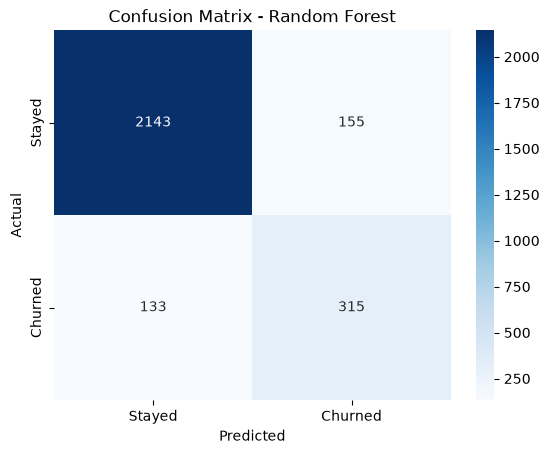

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### 8. Feature importance

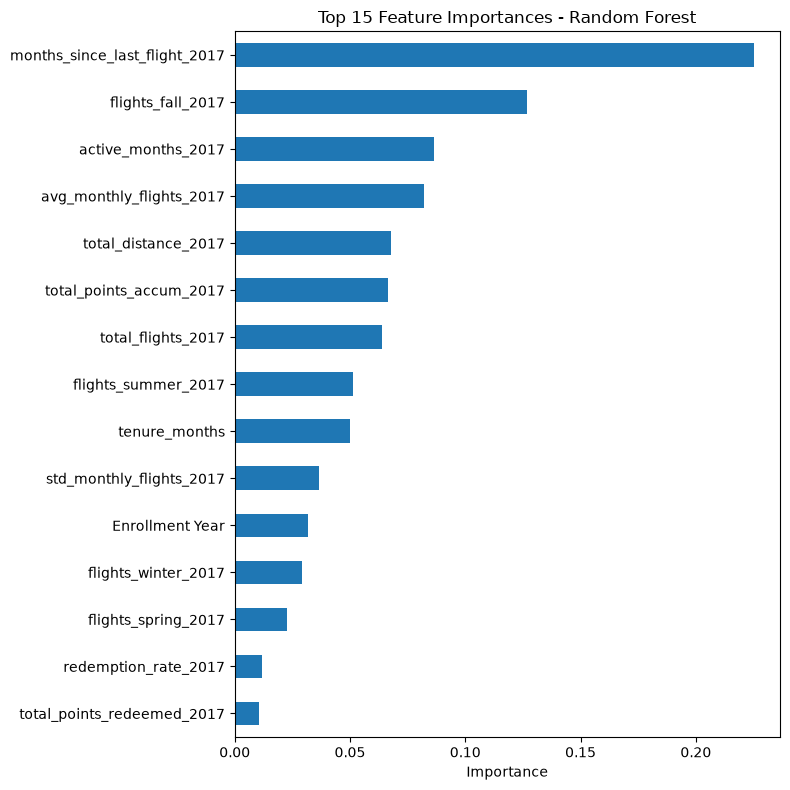

months_since_last_flight_2017    0.225237
flights_fall_2017                0.126811
active_months_2017               0.086275
avg_monthly_flights_2017         0.082306
total_distance_2017              0.067983
total_points_accum_2017          0.066279
total_flights_2017               0.064076
flights_summer_2017              0.051226
tenure_months                    0.050088
std_monthly_flights_2017         0.036476
Enrollment Year                  0.031675
flights_winter_2017              0.029091
flights_spring_2017              0.022885
redemption_rate_2017             0.011882
total_points_redeemed_2017       0.010484
dtype: float64


In [23]:
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.head(15))

## 9. Visualizations for the report

### 9.1 Overall churn rate

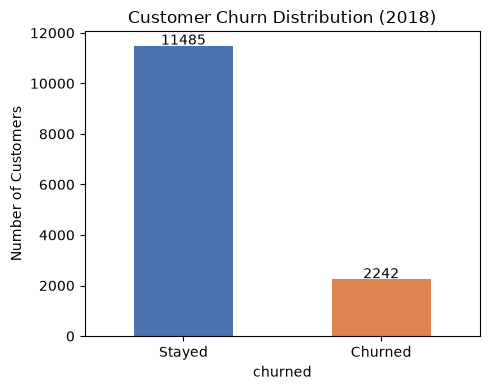

In [24]:
plt.figure(figsize=(5,4))
df['churned'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.xticks([0,1], ['Stayed', 'Churned'], rotation=0)
plt.title('Customer Churn Distribution (2018)')
plt.ylabel('Number of Customers')
for i, v in enumerate(df['churned'].value_counts()):
    plt.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.savefig("../outputs/churn_distribution.png", dpi=150)
plt.show()

### 9.2 Churn rate by Loyalty Card tier

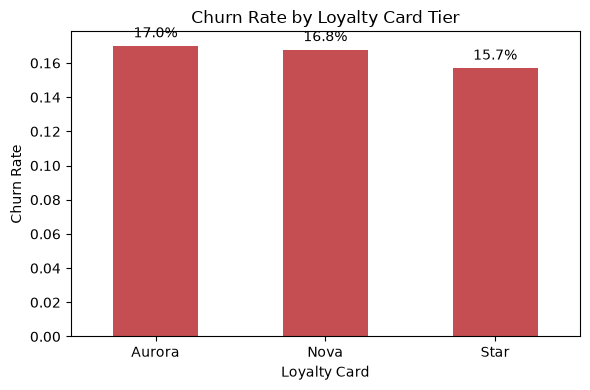

In [25]:
churn_by_card = df.groupby('Loyalty Card')['churned'].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
churn_by_card.plot(kind='bar', color='#C44E52')
plt.title('Churn Rate by Loyalty Card Tier')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
for i, v in enumerate(churn_by_card):
    plt.text(i, v + 0.005, f"{v:.1%}", ha='center')
plt.tight_layout()
plt.savefig("../outputs/churn_by_card.png", dpi=150)
plt.show()

### 9.3 Churn rate by tenure (binned)

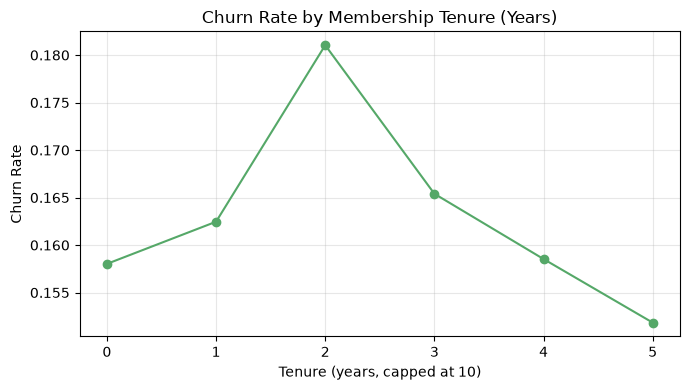

In [26]:
df['tenure_years'] = (df['tenure_months'] // 12).clip(upper=10)
churn_by_tenure = df.groupby('tenure_years')['churned'].mean()

plt.figure(figsize=(7,4))
churn_by_tenure.plot(kind='line', marker='o', color='#55A868')
plt.title('Churn Rate by Membership Tenure (Years)')
plt.xlabel('Tenure (years, capped at 10)')
plt.ylabel('Churn Rate')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/churn_by_tenure.png", dpi=150)
plt.show()

### 9.4 Churn rate vs. months since last flight in 2017

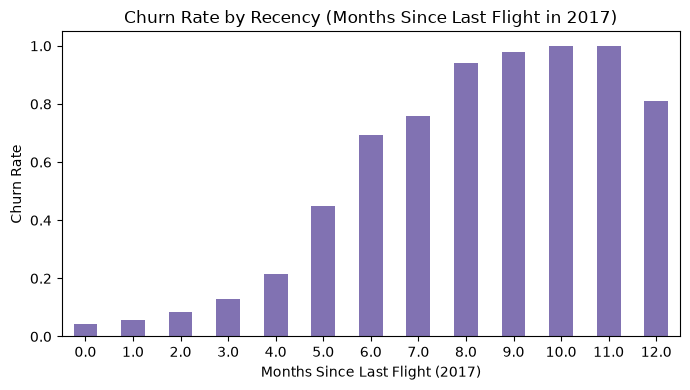

In [27]:
churn_by_recency = df.groupby('months_since_last_flight_2017')['churned'].mean()

plt.figure(figsize=(7,4))
churn_by_recency.plot(kind='bar', color='#8172B2')
plt.title('Churn Rate by Recency (Months Since Last Flight in 2017)')
plt.xlabel('Months Since Last Flight (2017)')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/churn_by_recency.png", dpi=150)
plt.show()

### 9.5 ROC Curve comparison (Logistic Regression vs Random Forest)

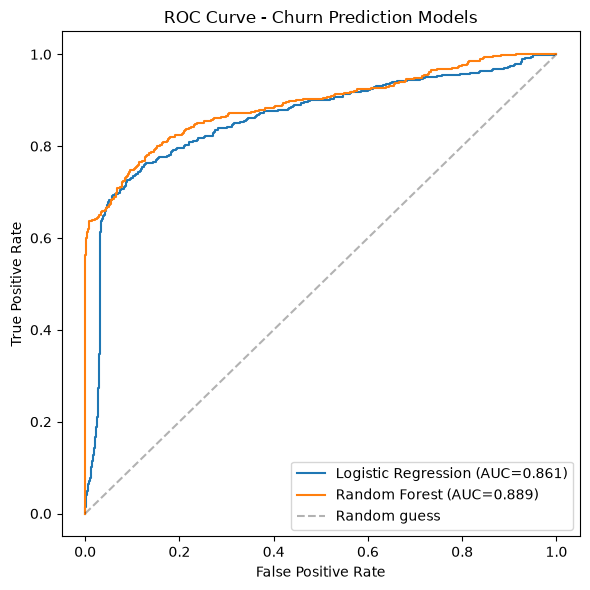

In [28]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_proba):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction Models')
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/roc_curve.png", dpi=150)
plt.show()

### 9.6 CLV distribution by churn status

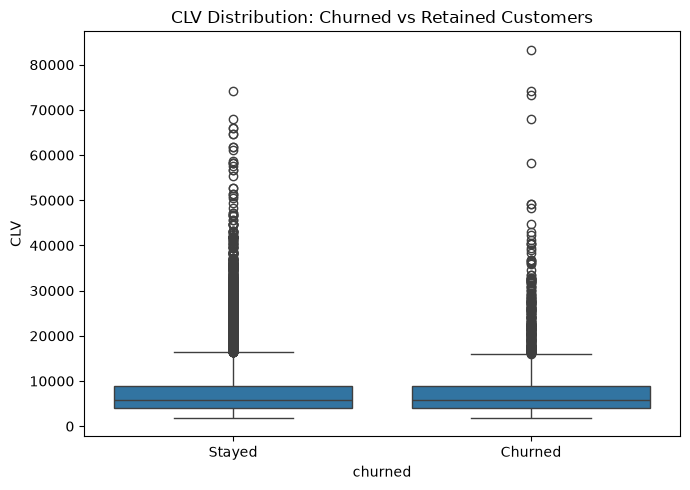

In [29]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='churned', y='CLV')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.title('CLV Distribution: Churned vs Retained Customers')
plt.tight_layout()
plt.savefig("../outputs/clv_by_churn.png", dpi=150)
plt.show()

### 9. Save the trained model for use in the dashboard

In [30]:
import joblib
import os

os.makedirs("../src/model", exist_ok=True)

joblib.dump(rf, "../src/model/churn_rf_model.pkl")
joblib.dump(X_encoded.columns.tolist(), "../src/model/model_columns.pkl")

print("Model and column list saved.")

Model and column list saved.
